### Import Dependencies

In [ ]:
import sys
print(sys.executable)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import torch

In [6]:
import torch
from torchvision import datasets, transforms, models  # datsets  , transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime

### Import Dataset

<b> Dataset Link (Plant Vliiage Dataset ):</b><br> <a href='https://data.mendeley.com/datasets/tywbtsjrjv/1'> https://data.mendeley.com/datasets/tywbtsjrjv/1 </a> 

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [8]:
dataset = datasets.ImageFolder("../Dataset", transform=transform)

num_classes = len(dataset.class_to_idx)

print("Number of classes:", num_classes)
print("Total images:", len(dataset))

Number of classes: 39
Total images: 55448


In [9]:
dataset

Dataset ImageFolder
    Number of datapoints: 55448
    Root location: ../Dataset
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [12]:
import numpy as np

dataset_size = len(dataset)
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_size = int(0.3* dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

print(f"Train size: {len(train_indices)}")
print(f"Validation size: {len(val_indices)}")
print(f"Test size: {len(test_indices)}")

Train size: 16634
Validation size: 5544
Test size: 33270


### Split into Train and Test

In [13]:
import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler

dataset_size = len(dataset)
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_indices = indices[:train_size]
validation_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

print(f"Train size: {len(train_indices)}")
print(f"Validation size: {len(validation_indices)}")
print(f"Test size: {len(test_indices)}")

train_sampler = SubsetRandomSampler(train_indices)
validation_sampler = SubsetRandomSampler(validation_indices)
test_sampler = SubsetRandomSampler(test_indices)

targets_size = num_classes

Train size: 44358
Validation size: 5544
Test size: 5546


### Model

<b>Convolution Aithmetic Equation : </b>(W - F + 2P) / S + 1 <br>
W = Input Size<br>
F = Filter Size<br>
P = Padding Size<br>
S = Stride <br>

### Transfer Learning

In [15]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

# Freeze earlier layers (important for faster training)
for param in model.parameters():
    param.requires_grad = False

# Replace final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, targets_size)

model = model.to(device)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Original Modeling

In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

### Batch Gradient Descent

In [18]:
def batch_gd(model, criterion, train_loader, validation_loader, epochs):
    train_losses = np.zeros(epochs)
    validation_losses = np.zeros(epochs)

    for e in range(epochs):
        t0 = datetime.now()

        # ---- TRAIN MODE ----
        model.train()
        train_loss = []

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            train_loss.append(loss.item())

            loss.backward()
            optimizer.step()

        train_loss = np.mean(train_loss)

        # ---- VALIDATION MODE ----
        model.eval()
        validation_loss = []

        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                validation_loss.append(loss.item())

        validation_loss = np.mean(validation_loss)

        train_losses[e] = train_loss
        validation_losses[e] = validation_loss

        dt = datetime.now() - t0

        print(
            f"Epoch: {e+1}/{epochs} "
            f"Train Loss: {train_loss:.3f} "
            f"Val Loss: {validation_loss:.3f} "
            f"Time: {dt}"
        )

    return train_losses, validation_losses

In [19]:
device = "cpu"

In [20]:
batch_size = 16  # CPU safe

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    num_workers=2,      # improves loading speed
    pin_memory=True
)

validation_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    sampler=validation_sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    sampler=test_sampler,
    num_workers=2,
    pin_memory=True
)

In [21]:
train_losses, validation_losses = batch_gd(
    model, criterion, train_loader, validation_loader, 2
)

d:\Plant-Disease-Detection\venv\lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1/2 Train Loss: 0.494 Val Loss: 0.188 Time: 0:37:31.686957
Epoch: 2/2 Train Loss: 0.215 Val Loss: 0.164 Time: 0:40:48.445970


### Save the Model

In [ ]:
# torch.save(model.state_dict() , 'plant_disease_model_1.pt')

### Load Model

In [83]:
import os
print(os.listdir())

['model.JPG', 'Plant Disease Detection Code.ipynb', 'Plant Disease Detection Code.md', 'Plant Disease Detection-code.pdf', 'Readme.md']


In [35]:
torch.save(model.state_dict(), "plant_disease_model_1_latest.pt")
print("Model saved successfully!")

Model saved successfully!


In [36]:
import os
print(os.listdir("../Dataset"))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tom

In [37]:
import torch
import torch.nn as nn
import torchvision.models as models

targets_size = 39

# Create same model architecture as training
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, targets_size)

# Load trained weights
model.load_state_dict(torch.load("plant_disease_model_1_latest.pt", map_location=torch.device('cpu')))

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


d:\Plant-Disease-Detection\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Plant-Disease-Detection\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [38]:
import os

class_folder = os.listdir("../Dataset")[0]
class_path = os.path.join("../Dataset", class_folder)

sample_image = os.listdir(class_path)[0]
img_path = os.path.join(class_path, sample_image)

print("Testing image:", img_path)

from PIL import Image
image = Image.open(img_path).convert("RGB")

Testing image: ../Dataset\Apple___Apple_scab\image (1).JPG


In [39]:
image = transform(image)
image = image.unsqueeze(0)

with torch.no_grad():
    output = model(image)
    probs = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probs, 1)

print("Predicted index:", predicted.item())
print("Confidence:", confidence.item())

Predicted index: 7
Confidence: 0.3338839113712311


In [40]:
from collections import Counter

train_targets = []

for _, label in train_loader:
    train_targets.extend(label.numpy())

print(Counter(train_targets))

d:\Plant-Disease-Detection\venv\lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Counter({np.int64(16): 4450, np.int64(36): 4275, np.int64(25): 4059, np.int64(17): 1812, np.int64(29): 1692, np.int64(31): 1497, np.int64(26): 1464, np.int64(33): 1402, np.int64(34): 1354, np.int64(3): 1322, np.int64(38): 1255, np.int64(5): 1238, np.int64(20): 1217, np.int64(35): 1107, np.int64(13): 1097, np.int64(9): 946, np.int64(11): 944, np.int64(4): 920, np.int64(12): 909, np.int64(27): 894, np.int64(14): 865, np.int64(6): 845, np.int64(19): 821, np.int64(22): 799, np.int64(10): 795, np.int64(30): 795, np.int64(21): 791, np.int64(32): 767, np.int64(7): 682, np.int64(0): 503, np.int64(1): 496, np.int64(8): 410, np.int64(28): 365, np.int64(15): 337, np.int64(37): 302, np.int64(24): 297, np.int64(18): 291, np.int64(2): 231, np.int64(23): 112})


In [41]:
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
for k, v in Counter(train_targets).items():
    print(idx_to_class[k], ":", v)

Orange___Haunglongbing_(Citrus_greening) : 4450
Apple___healthy : 1322
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 4275
Corn___Northern_Leaf_Blight : 795
Potato___Late_blight : 799
Corn___Common_rust : 946
Tomato___Spider_mites Two-spotted_spider_mite : 1354
Strawberry___healthy : 365
Corn___healthy : 944
Peach___Bacterial_spot : 1812
Soybean___healthy : 4059
Peach___healthy : 291
Tomato___Target_Spot : 1107
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 865
Tomato___Early_blight : 795
Tomato___healthy : 1255
Pepper,_bell___Bacterial_spot : 821
Squash___Powdery_mildew : 1464
Potato___Early_blight : 791
Tomato___Bacterial_spot : 1692
Grape___Esca_(Black_Measles) : 1097
Tomato___Late_blight : 1497
Cherry___Powdery_mildew : 845
Apple___Apple_scab : 503
Strawberry___Leaf_scorch : 894
Tomato___Leaf_Mold : 767
Cherry___healthy : 682
Background_without_leaves : 920
Grape___Black_rot : 909
Apple___Black_rot : 496
Blueberry___healthy : 1238
Raspberry___healthy : 297
Tomato___Septoria_leaf_spot : 140

In [ ]:
# %matplotlib notebook

### Plot the loss

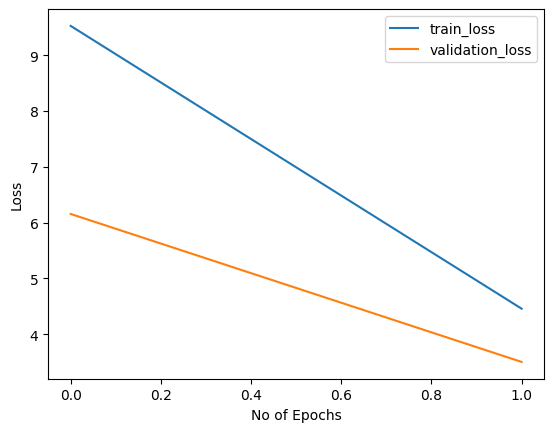

In [87]:
plt.plot(train_losses , label = 'train_loss')
plt.plot(validation_losses , label = 'validation_loss')
plt.xlabel('No of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Accuracy

In [88]:
def accuracy(loader):
    n_correct = 0
    n_total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)

        _, predictions = torch.max(outputs, 1)

        n_correct += (predictions == targets).sum().item()
        n_total += targets.shape[0]

    acc = n_correct / n_total
    return acc

In [89]:
train_acc = accuracy(train_loader)
test_acc = accuracy(test_loader)
validation_acc = accuracy(validation_loader)

In [90]:
print(
    f"Train Accuracy : {train_acc}\nTest Accuracy : {test_acc}\nValidation Accuracy : {validation_acc}"
)

Train Accuracy : 0.007563025210084034
Test Accuracy : 0.013333333333333334
Validation Accuracy : 0.00392156862745098


### Single Image Prediction

In [91]:
transform_index_to_disease = dataset.class_to_idx

AttributeError: 'Subset' object has no attribute 'class_to_idx'

In [ ]:
transform_index_to_disease = dict(
    [(value, key) for key, value in transform_index_to_disease.items()]
)  # reverse the index

In [ ]:
data = pd.read_csv("disease_info.csv", encoding="cp1252")

In [ ]:
from PIL import Image
import torchvision.transforms.functional as TF

In [ ]:
def single_prediction(image_path):
    image = Image.open(image_path)
    image = image.resize((224, 224))
    input_data = TF.to_tensor(image)
    input_data = input_data.view((-1, 3, 224, 224))
    output = model(input_data)
    output = output.detach().numpy()
    index = np.argmax(output)
    print("Original : ", image_path[12:-4])
    pred_csv = data["disease_name"][index]
    print(pred_csv)

In [ ]:
single_prediction("test_images/Apple_ceder_apple_rust.JPG")

### Wrong Prediction

In [ ]:
single_prediction("test_images/Apple_scab.JPG")

In [ ]:
single_prediction("test_images/Grape_esca.JPG")

In [ ]:
single_prediction("test_images/apple_black_rot.JPG")

In [ ]:
single_prediction("test_images/apple_healthy.JPG")

In [ ]:
single_prediction("test_images/background_without_leaves.jpg")

In [ ]:
single_prediction("test_images/blueberry_healthy.JPG")

In [ ]:
single_prediction("test_images/cherry_healthy.JPG")

In [ ]:
single_prediction("test_images/cherry_powdery_mildew.JPG")

In [ ]:
single_prediction("test_images/corn_cercospora_leaf.JPG")

In [ ]:
single_prediction("test_images/corn_common_rust.JPG")

In [ ]:
single_prediction("test_images/corn_healthy.jpg")

In [ ]:
single_prediction("test_images/corn_northen_leaf_blight.JPG")

In [ ]:
single_prediction("test_images/grape_black_rot.JPG")

In [ ]:
single_prediction("test_images/grape_healthy.JPG")

In [ ]:
single_prediction("test_images/grape_leaf_blight.JPG")

In [ ]:
single_prediction("test_images/orange_haunglongbing.JPG")

In [ ]:
single_prediction("test_images/peach_bacterial_spot.JPG")

In [ ]:
single_prediction("test_images/peach_healthy.JPG")

In [ ]:
single_prediction("test_images/pepper_bacterial_spot.JPG")

In [ ]:
single_prediction("test_images/pepper_bell_healthy.JPG")

In [ ]:
single_prediction("test_images/potato_early_blight.JPG")

In [ ]:
single_prediction("test_images/potato_healthy.JPG")

In [ ]:
single_prediction("test_images/potato_late_blight.JPG")

In [ ]:
single_prediction("test_images/raspberry_healthy.JPG")

In [ ]:
single_prediction("test_images/soyaben healthy.JPG")

In [ ]:
single_prediction("test_images/potato_late_blight.JPG")

In [ ]:
single_prediction("test_images/squash_powdery_mildew.JPG")

In [ ]:
single_prediction("test_images/starwberry_healthy.JPG")

In [ ]:
single_prediction("test_images/starwberry_leaf_scorch.JPG")

In [ ]:
single_prediction("test_images/tomato_bacterial_spot.JPG")

In [ ]:
single_prediction("test_images/tomato_early_blight.JPG")

In [ ]:
single_prediction("test_images/tomato_healthy.JPG")

In [ ]:
single_prediction("test_images/tomato_late_blight.JPG")

In [ ]:
single_prediction("test_images/tomato_leaf_mold.JPG")

In [ ]:
single_prediction("test_images/tomato_mosaic_virus.JPG")

In [ ]:
single_prediction("test_images/tomato_septoria_leaf_spot.JPG")

In [ ]:
single_prediction("test_images/tomato_spider_mites_two_spotted_spider_mites.JPG")

In [ ]:
single_prediction("test_images/tomato_target_spot.JPG")

In [ ]:
single_prediction("test_images/tomato_yellow_leaf_curl_virus.JPG")